In [18]:
from numpy import *
import operator
from matplotlib import pyplot as plt
import os

def createDataSet():
    group=array([[1.0,1.1],[1.0,1.0],[0,0],[0,0.1]])
    labels=['A','A','B','B']
    return group, labels

def classify0(inX, dataSet, labels, k):
    dataSetSize=dataSet.shape[0]
    diffMat=tile(inX,(dataSetSize,1))-dataSet
    sqDiffMat=diffMat**2
    sqDistances=sqDiffMat.sum(axis=1)
    distances=sqDistances**0.5
    sortedDistIndicies=distances.argsort()
    classCount={}
    for i in range(k):
        voteIlabel=labels[sortedDistIndicies[i]]
        classCount[voteIlabel]=classCount.get(voteIlabel,0)+1
    sortedClassCount=sorted(classCount.items(),
                            key=operator.itemgetter(1),reverse=True)
    return sortedClassCount[0][0]


def file2matrix(filename):
    with open(filename,'r') as fr:
        arrayOLines=fr.readlines()
        numberOflines=len(arrayOLines)
        returnMat=zeros((numberOflines,3))
        classLabelVector=[]
        index=0
        for line in arrayOLines:
            line=line.strip()
            listFromLine=line.split('\t')
            returnMat[index,:]=listFromLine[0:3]
            classLabelVector.append(int(listFromLine[-1]))
            index+=1
    return returnMat,classLabelVector


def autoNorm(dataSet):
    minVals=dataSet.min(0)
    maxVals=dataSet.max(0)
    ranges=maxVals-minVals
    normDataSet=zeros(shape(dataSet))
    m=dataSet.shape[0]
    normDataSet=dataSet-tile(minVals,(m,1))
    normDataSet=normDataSet/tile(ranges,(m,1))
    return normDataSet, ranges, minVals

def datingClassTest():
    hoRatio=0.10
    datingDataMat,datingLabels=file2matrix('../dataset/Ch02-KNN/datingTestSet2.txt')
    normMat, ranges, minVals = autoNorm(datingDataMat) 
    m=normMat.shape[0]
    numTestVecs=int(m*hoRatio)
    errorCount=0.0
    for i in range(numTestVecs):
        classifierResult=classify0(normMat[i,:],normMat[numTestVecs:m,:],
                                    datingLabels[numTestVecs:m],3)
        print('the classifier came back with:%d,the real answer is:%d'%( classifierResult,datingLabels[i]))     
        if(classifierResult!=datingLabels[i]):
            errorCount+=1.0
    print('the total number of errors is: %d'% errorCount )
    print('the total error rate is: %f' % (errorCount/float(numTestVecs)))

def img2vector(filename):
    returnVect = zeros((1,1024))
    fr = open(filename)
    for i in range(32):
        lineStr = fr.readline()
        for j in range(32):
            returnVect[0,32*i+j] = int(lineStr[j])
    return returnVect

def handwritingClassTest():
    hwLabels = []
    trainingFileList = os.listdir('../dataset/Ch02-KNN/trainingDigits')           #load the training set
    m = len(trainingFileList)
    trainingMat = zeros((m,1024))
    for i in range(m):
        fileNameStr = trainingFileList[i]
        fileStr = fileNameStr.split('.')[0]     #take off .txt
        classNumStr = int(fileStr.split('_')[0])
        hwLabels.append(classNumStr)
        trainingMat[i,:] = img2vector('../dataset/Ch02-KNN/trainingDigits/%s' % fileNameStr)
    testFileList = os.listdir('../dataset/Ch02-KNN/testDigits')        #iterate through the test set
    errorCount = 0.0
    mTest = len(testFileList)
    for i in range(mTest):
        fileNameStr = testFileList[i]
        fileStr = fileNameStr.split('.')[0]     #take off .txt
        classNumStr = int(fileStr.split('_')[0])
        vectorUnderTest = img2vector('../dataset/Ch02-KNN/testDigits/%s' % fileNameStr)
        classifierResult = classify0(vectorUnderTest, trainingMat, hwLabels, 3)
        print ("the classifier came back with: %d, the real answer is: %d" % (classifierResult, classNumStr))
        if (classifierResult != classNumStr): errorCount += 1.0
    print ("\nthe total number of errors is: %d" % errorCount)
    print ("\nthe total error rate is: %f" % (errorCount/float(mTest)))

In [8]:
group, labels = createDataSet()
print(classify0([0,0], group, labels, 3))
dataMat, labels = file2matrix('../dataset/Ch02-KNN/datingTestSet2.txt')
print(dataMat)
print(labels[0:20])


B
[[4.0920000e+04 8.3269760e+00 9.5395200e-01]
 [1.4488000e+04 7.1534690e+00 1.6739040e+00]
 [2.6052000e+04 1.4418710e+00 8.0512400e-01]
 ...
 [2.6575000e+04 1.0650102e+01 8.6662700e-01]
 [4.8111000e+04 9.1345280e+00 7.2804500e-01]
 [4.3757000e+04 7.8826010e+00 1.3324460e+00]]
[3, 2, 1, 1, 1, 1, 3, 3, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 2, 3]


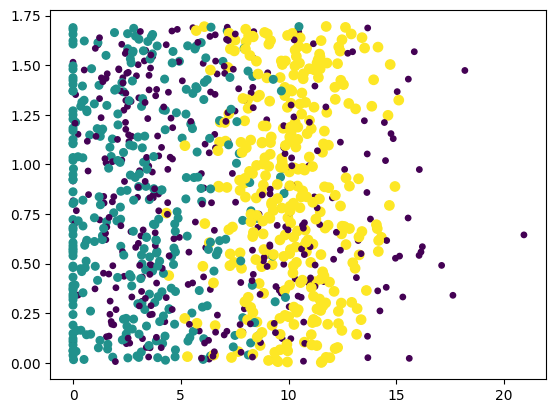

In [9]:
fig=plt.figure()
ax=fig.add_subplot(111)
ax.scatter(dataMat[:,1],dataMat[:,2],15.0*array(labels),15.0*array(labels))
plt.show()

In [10]:
normMat, ranges, minVals = autoNorm(dataMat)
print(normMat)
print(ranges)
print(minVals)

[[0.44832535 0.39805139 0.56233353]
 [0.15873259 0.34195467 0.98724416]
 [0.28542943 0.06892523 0.47449629]
 ...
 [0.29115949 0.50910294 0.51079493]
 [0.52711097 0.43665451 0.4290048 ]
 [0.47940793 0.3768091  0.78571804]]
[9.1273000e+04 2.0919349e+01 1.6943610e+00]
[0.       0.       0.001156]


In [14]:
datingClassTest()

the classifier came back with:3,the real answer is:3
the classifier came back with:2,the real answer is:2
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:3,the real answer is:3
the classifier came back with:3,the real answer is:3
the classifier came back with:1,the real answer is:1
the classifier came back with:3,the real answer is:3
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:2,the real answer is:2
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:1,the real answer is:1
the classifier came back with:2,the real answe

In [19]:
handwritingClassTest()

the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answer is: 0
the classifier came back with: 0, the real answe